In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2026-03-23 06:24:27.005607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774247067.219275      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774247067.280015      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774247067.800095      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774247067.800142      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774247067.800146      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


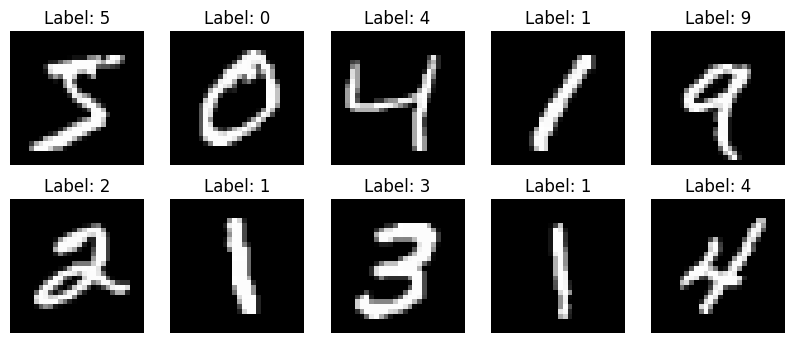

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-23 06:24:53.352204: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


In [ ]:
#Import Necessary Libraries
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Visualize The Training Data

plt.figure(figsize=(10, 4))  # Set The size Of The Figure
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Make subplots for 10 images
    plt.imshow(x_train[i], cmap='gray')  # Display The grayscale images
    plt.title(f"Label: {y_train[i]}")  # Add labels
    plt.axis('off')  # Axis Labels Turned Off
plt.show()  # Displaying the plot


#Data Processing
#Split The Data Into Training And Validation Set
#Here, we will split the data into the training and validation set.

# Consider The First 50000 samples As The Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

# Conside The Last 10000 Samples AS The Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]


#Normalize the Data
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

#Reshape data
#Change the shape of the arrays to include the color channel of the images. Since the images are grayscale, the color channel is 1.


x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


#One Hot Encoding
#Perform one-hot encoding to convert categorical data into binary vectors.
#Each element in the binary vector corresponds to a class, and only one element is 1, while the rest are 0.
#For example, if there are 10 classes and the label is 3, the one-hot encoded vector would be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)



#Build LeNet5 Model
#Create An Instance of Sequential Class.
LeNet5_Model=Sequential()

# Add First Convolutional Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# Add First Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Add Second Convolutional Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# Add Second Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Flatten The Layer
LeNet5_Model.add(Flatten())

# Add Dense Layer
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

#Compile The Model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


#Check Model Summary
LeNet5_Model.summary()


#Train The Model
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))


#Evaluate The Model Performance On The Test Dataset
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)





